In [1]:
import pandas as pd
import numpy as np
import warnings
import random
import math


warnings.filterwarnings('ignore')

In [2]:
df_placar2 = pd.read_csv("vlr_placar2.csv")
df_stats2 = pd.read_csv("vlr_stats2.csv")

df_merged = pd.read_csv("status_individual.csv")
df_impc = pd.read_csv("df_impacto_cada_mapa.csv")

In [3]:
df_impc

,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,...,HS%,FK,FD,+/-_FK_FD,Time1,Score_T1,Time2,Score_T2,target,Impacto
0,Haven,Darker,LOUD,Viper,1.12,256.0,18,16,6,2,...,30.0,2.0,1.0,1.0,LOUD,7,C9,13,0,0.821
1,Haven,cauanzin,LOUD,Sova,0.98,209.0,15,13,3,2,...,26.0,0.0,1.0,-1.0,LOUD,7,C9,13,0,0.734
2,Haven,Virtyy,LOUD,Yoru,0.70,178.0,14,16,4,-2,...,35.0,2.0,3.0,-1.0,LOUD,7,C9,13,0,0.492
3,Haven,pANcada,LOUD,Omen,0.67,145.0,11,13,1,-2,...,27.0,0.0,3.0,-3.0,LOUD,7,C9,13,0,0.478
4,Haven,lukxo,LOUD,Killjoy,0.65,192.0,13,16,3,-3,...,35.0,4.0,4.0,0.0,LOUD,7,C9,13,0,0.538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7785,Fracture,crashies,NRG,Skye,1.24,212.0,19,17,11,2,...,32.0,0.0,3.0,-3.0,LOUD,13,NRG,11,0,0.773
7786,Fracture,s0m,NRG,Brimstone,1.24,240.0,19,18,12,1,...,24.0,2.0,1.0,1.0,LOUD,13,NRG,11,0,0.819
7787,Fracture,Victor,NRG,Killjoy,0.83,168.0,16,17,1,-1,...,15.0,2.0,2.0,0.0,LOUD,13,NRG,11,0,0.520
7788,Fracture,ardiis,NRG,Jett,0.81,210.0,15,19,4,-4,...,15.0,6.0,3.0,3.0,LOUD,13,NRG,11,0,0.586


In [5]:
df_merged

,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,KAST,ADR,HS%,FK,FD,+/-_FK_FD,target
0,Haven,Darker,LOUD,Viper,1.12,256.0,18,16,6,2,70.0,166.0,30.0,2.0,1.0,1.0,0
1,Haven,Darker,LOUD,Viper,1.12,256.0,18,16,6,2,70.0,166.0,30.0,2.0,1.0,1.0,0
2,Haven,cauanzin,LOUD,Sova,0.98,209.0,15,13,3,2,75.0,152.0,26.0,0.0,1.0,-1.0,0
3,Haven,cauanzin,LOUD,Sova,0.98,209.0,15,13,3,2,75.0,152.0,26.0,0.0,1.0,-1.0,0
4,Haven,Virtyy,LOUD,Yoru,0.70,178.0,14,16,4,-2,55.0,102.0,35.0,2.0,3.0,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11235,Fracture,crashies,NRG,Skye,1.24,212.0,19,17,11,2,79.0,145.0,32.0,0.0,3.0,-3.0,0
11236,Fracture,s0m,NRG,Brimstone,1.24,240.0,19,18,12,1,75.0,155.0,24.0,2.0,1.0,1.0,0
11237,Fracture,Victor,NRG,Killjoy,0.83,168.0,16,17,1,-1,67.0,110.0,15.0,2.0,2.0,0.0,0
11238,Fracture,ardiis,NRG,Jett,0.81,210.0,15,19,4,-4,71.0,141.0,15.0,6.0,3.0,3.0,0


# Visualização dos DF's

In [8]:
df_impc[df_impc["Jogador"] == "lukxo"].head(5)

,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,...,HS%,FK,FD,+/-_FK_FD,Time1,Score_T1,Time2,Score_T2,target,Impacto
8,Haven,lukxo,LOUD,Killjoy,0.65,192.0,13,16,3,-3,...,35.0,4.0,4.0,0.0,LOUD,7,C9,13,0,0.538
9,Haven,lukxo,LOUD,Killjoy,0.65,192.0,13,16,3,-3,...,35.0,4.0,4.0,0.0,LOUD,7,C9,13,0,0.538
20,Abyss,lukxo,LOUD,Chamber,1.46,297.0,27,16,3,11,...,34.0,4.0,2.0,2.0,LOUD,11,C9,13,0,0.892
21,Abyss,lukxo,LOUD,Chamber,1.46,297.0,27,16,3,11,...,34.0,4.0,2.0,2.0,LOUD,11,C9,13,0,0.892
406,Breeze,lukxo,LOUD,Viper,1.04,181.0,16,16,5,0,...,34.0,2.0,7.0,-5.0,LOUD,13,100T,11,1,0.649


In [9]:
df_merged[df_merged["Jogador"] == "Darker"].head(5)

,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,KAST,ADR,HS%,FK,FD,+/-_FK_FD,target
0,Haven,Darker,LOUD,Viper,1.12,256.0,18,16,6,2,70.0,166.0,30.0,2.0,1.0,1.0,0
1,Haven,Darker,LOUD,Viper,1.12,256.0,18,16,6,2,70.0,166.0,30.0,2.0,1.0,1.0,0
22,Abyss,Darker,LOUD,Astra,0.95,166.0,15,16,8,-1,75.0,101.0,31.0,1.0,3.0,-2.0,0
23,Abyss,Darker,LOUD,Astra,0.95,166.0,15,16,8,-1,75.0,101.0,31.0,1.0,3.0,-2.0,0
404,Breeze,Darker,LOUD,Kayo,1.06,187.0,16,16,5,0,75.0,128.0,18.0,2.0,3.0,-1.0,1


In [44]:
def perfil_historico(nome, df):
    jogador = df[df['Jogador'] == nome].copy()
    
    if jogador.empty:
        print(f"Jogador '{nome}' não encontrado!")
        return
    
    cols_soma  = ['K', 'D', 'A', '+/-', 'FK', 'FD', '+/-_FK_FD']
    cols_media = ['R', 'ACS', 'KAST', 'ADR', 'HS%', 'Impacto']
    
    soma  = jogador[cols_soma].sum()
    media = jogador[cols_media].mean()
    
    # Por mapa
    por_mapa = jogador.groupby('Mapa')[['Impacto', 'ACS', 'target']].mean().round(3)
    por_mapa.columns = ['Impacto_med', 'ACS_med', 'Win_Rate']
    por_mapa = por_mapa.sort_values('Impacto_med', ascending=False)
    
    # Por agente
    por_agente = jogador.groupby('Agente')[['Impacto', 'ACS', 'target']].mean().round(3)
    por_agente.columns = ['Impacto_med', 'ACS_med', 'Win_Rate']
    por_agente = por_agente.sort_values('Impacto_med', ascending=False)

    print(f"=== Perfil Histórico: {nome} ===")
    print(f"Partidas : {len(jogador)}")
    print(f"Win Rate : {jogador['target'].mean():.1%}")
    print(f"Time(s)  : {', '.join(jogador['Time'].unique())}")
    print(f"Mapas    : {jogador['Mapa'].nunique()} diferentes")
    print()
    
    print("--- Médias ---")
    for col, val in media.items():
        print(f"  {col:<10}: {val:.3f}")
    print()
    
    print("--- Totais ---")
    for col, val in soma.items():
        print(f"  {col:<15}: {int(val)}")
    print()
    
    print("--- Por Mapa (ordenado por Impacto) ---")
    for mapa, row in por_mapa.iterrows():
        print(f"  {mapa:<12} | Impacto: {row['Impacto_med']:.3f} | ACS: {row['ACS_med']:.0f} | Win Rate: {row['Win_Rate']:.1%}")
    print()
    
    print("--- Por Agente (ordenado por Impacto) ---")
    for agente, row in por_agente.iterrows():
        print(f"  {agente:<12} | Impacto: {row['Impacto_med']:.3f} | ACS: {row['ACS_med']:.0f} | Win Rate: {row['Win_Rate']:.1%}")

perfil_historico('cortezia', df_impc)

=== Perfil Histórico: cortezia ===
Partidas : 130
Win Rate : 50.8%
Time(s)  : SEN, MIBR
Mapas    : 12 diferentes

--- Médias ---
  R         : 0.948
  ACS       : 192.985
  KAST      : 69.000
  ADR       : 129.215
  HS%       : 34.892
  Impacto   : 0.660

--- Totais ---
  K              : 2004
  D              : 1984
  A              : 590
  +/-            : 20
  FK             : 252
  FD             : 243
  +/-_FK_FD      : 9

--- Por Mapa (ordenado por Impacto) ---
  Bind         | Impacto: 0.730 | ACS: 221 | Win Rate: 27.3%
  Icebox       | Impacto: 0.717 | ACS: 203 | Win Rate: 100.0%
  Haven        | Impacto: 0.696 | ACS: 193 | Win Rate: 61.5%
  Abyss        | Impacto: 0.683 | ACS: 196 | Win Rate: 80.0%
  Pearl        | Impacto: 0.673 | ACS: 190 | Win Rate: 83.3%
  Split        | Impacto: 0.651 | ACS: 196 | Win Rate: 54.2%
  Breeze       | Impacto: 0.643 | ACS: 186 | Win Rate: 40.0%
  Sunset       | Impacto: 0.638 | ACS: 206 | Win Rate: 50.0%
  Corrode      | Impacto: 0.631 | ACS: 

# Gerar Times Aleatórios

In [6]:
def gerar_time_aleatorio(df, n=5, seed=None):
    time = df.sample(n=n, random_state=seed).reset_index(drop=True)

    cols_soma = [
        'K', 'D', 'A', '+/-',
        'FK', 'FD', '+/-_FK_FD'
    ]

    cols_media = [
        'R', 'ACS', 'KAST',
        'ADR', 'HS%', 'Impacto'
    ]

    soma = time[cols_soma].sum()
    media = time[cols_media].mean()

    total = pd.concat([soma, media])

    total['Jogador'] = 'TOTAL'
    total['Mapa'] = '-'
    total['Time'] = '-'
    total['Agente'] = '-'
    total['Score_T1'] = '-'
    total['Score_T2'] = '-'
    total['target'] = '-'

    time = pd.concat([time, total.to_frame().T], ignore_index=True)

    return time


time = gerar_time_aleatorio(df_impc)
time

,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,...,HS%,FK,FD,+/-_FK_FD,Time1,Score_T1,Time2,Score_T2,target,Impacto
0,Haven,nataNk,LEV,Breach,1.12,192,13,12,14,1,...,23,2,2,0,LEV,13,FUR,8,1,0.743
1,Haven,tex,MIBR,Killjoy,0.87,196,16,16,2,0,...,33,1,1,0,MIBR,11,FUR,13,0,0.646
2,Haven,lz,2G,Omen,0.88,181,12,14,9,-2,...,42,2,2,0,2G,7,FUR,13,0,0.574
3,Corrode,RobbieBk,LOUD,Fade,0.58,97,8,15,1,-7,...,35,1,2,-1,NRG,13,LOUD,9,0,0.397
4,Bind,jawgemo,G2,Yoru,1.11,227,18,14,5,4,...,19,3,3,0,SEN,8,G2,13,1,0.765
5,-,TOTAL,-,-,0.912,178.6,67.0,71.0,31.0,-4.0,...,30.4,9.0,10.0,-1.0,NaN,-,NaN,-,-,0.625


In [7]:
def gerar_time_aleatorio(df, n=5, seed=None):
    time = df.sample(n=n, random_state=seed).reset_index(drop=True)

    cols_soma = [
        'K', 'D', 'A',
        '+/-', 'FK', 'FD',
        '+/-_FK_FD'
    ]

    cols_media = [
        'R', 'ACS', 'KAST',
        'ADR', 'HS%'
    ]

    soma = time[cols_soma].sum()
    media = time[cols_media].mean()

    total = pd.concat([soma, media])

    total['Mapa'] = '-'
    total['Jogador'] = 'TOTAL'
    total['Time'] = '-'
    total['Agente'] = '-'
    total['target'] = '-'

    time = pd.concat([time, total.to_frame().T], ignore_index=True)

    return time


time = gerar_time_aleatorio(df_merged)
time

,Mapa,Jogador,Time,Agente,R,ACS,K,D,A,+/-,KAST,ADR,HS%,FK,FD,+/-_FK_FD,target
0,Corrode,Sato,LEV,Waylay,1.3,286,23,18,5,5,65,166,17,4,4,0,1
1,Split,Sato,LEV,Yoru,1.43,285,24,14,2,10,68,179,34,3,4,-1,0
2,Abyss,artzin,FUR,Astra,1.22,201,14,12,9,2,80,142,44,2,2,0,1
3,Bind,trent,G2,Tejo,0.79,144,11,14,6,-3,62,97,24,2,3,-1,1
4,Split,Khalil,FUR,Omen,0.64,160,10,17,5,-7,68,103,46,2,3,-1,0
5,-,TOTAL,-,-,1.076,215.2,82.0,75.0,27.0,7.0,68.6,137.4,33.0,13.0,16.0,-3.0,-


# Aplicação de ML

-Descobrir melhores combinações de agente + mapa

-Sistema de recomendação de agentes

-Simulador de partidas

In [6]:
def gerar_dataset_pairwise(df):
    cols_soma = ['K', 'D', 'A', '+/-', 'FK', 'FD', '+/-_FK_FD']
    cols_media = ['R', 'ACS', 'KAST', 'ADR', 'HS%', 'Impacto']
    
    rows = []
    
    # Itera de 10 em 10, pois mostra um confronto direto
    for i in range(0, len(df), 10):
        bloco = df.iloc[i:i+10]
        
        time_a = bloco.iloc[:5]   
        time_b = bloco.iloc[5:]   
        
        vetor_a = pd.concat([time_a[cols_soma].sum(), time_a[cols_media].mean()])
        vetor_b = pd.concat([time_b[cols_soma].sum(), time_b[cols_media].mean()])
        
        diff = vetor_a - vetor_b
        diff.index = [f"diff_{c}" for c in diff.index]
        
        diff['Mapa']  = bloco['Mapa'].iloc[0]
        diff['Time1'] = bloco['Time1'].iloc[0]
        diff['Time2'] = bloco['Time2'].iloc[0]
        diff['target'] = bloco['target'].iloc[0]  
        
        rows.append(diff)
    
    return pd.DataFrame(rows).reset_index(drop=True)

df_pairwise = gerar_dataset_pairwise(df_impc)
df_pairwise

,diff_K,diff_D,diff_A,diff_+/-,diff_FK,diff_FD,diff_+/-_FK_FD,diff_R,diff_ACS,diff_KAST,diff_ADR,diff_HS%,diff_Impacto,Mapa,Time1,Time2,target
0,18.0,0.0,10.0,18.0,-4.0,-10.0,6.0,0.312,51.2,8.0,37.6,-2.4,0.2156,Haven,LOUD,C9,0
1,24.0,-12.0,-2.0,36.0,10.0,4.0,6.0,0.336,53.6,0.0,21.2,4.4,0.2044,Haven,LOUD,C9,1
2,32.0,-14.0,0.0,46.0,2.0,-6.0,8.0,0.396,50.8,8.0,18.8,6.0,0.1556,Abyss,LOUD,C9,0
3,18.0,-14.0,-4.0,32.0,-6.0,2.0,-8.0,0.268,30.4,1.2,26.0,-7.2,0.1512,Abyss,LOUD,C9,1
4,36.0,-26.0,4.0,62.0,2.0,-10.0,12.0,0.636,61.6,6.4,35.6,-0.8,0.2628,Bind,G2,100T,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119,-17.0,17.0,6.0,-34.0,-3.0,3.0,-6.0,-0.230,-28.2,-13.0,-11.8,5.4,-0.0816,Lotus,EG,NRG,0
1120,-24.0,24.0,-20.0,-48.0,-3.0,3.0,-6.0,-0.582,-69.6,-24.4,-45.8,-3.2,-0.2816,Split,EG,NRG,0
1121,3.0,-3.0,-4.0,6.0,-4.0,4.0,-8.0,0.076,4.0,1.8,-4.4,-4.2,0.0004,Ascent,LOUD,NRG,1
1122,12.0,-12.0,-5.0,24.0,8.0,-8.0,16.0,0.104,13.2,10.8,4.2,-1.6,0.1072,Bind,LOUD,NRG,1


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1209
           1       0.87      0.82      0.85      1039

    accuracy                           0.86      2248
   macro avg       0.86      0.86      0.86      2248
weighted avg       0.86      0.86      0.86      2248



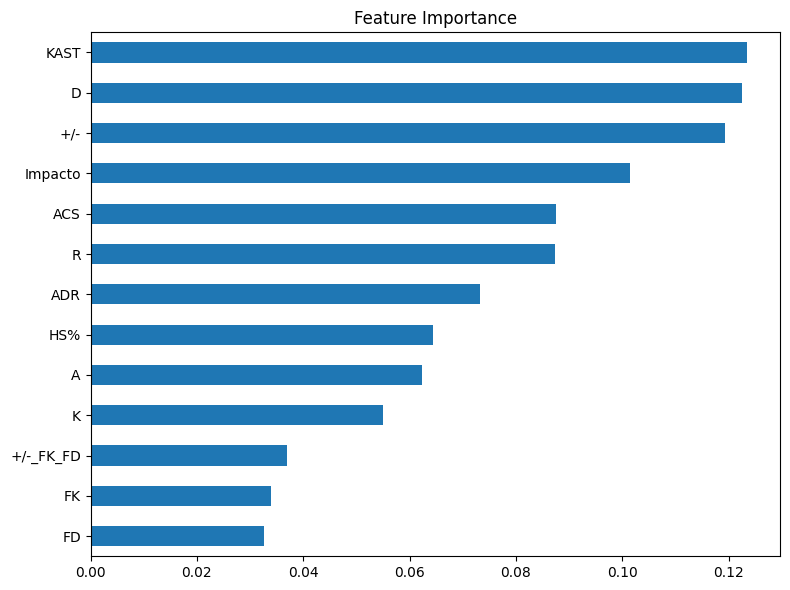

CV Accuracy: 0.753 ± 0.009


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


feature_cols = [
    'R', 'ACS', 'K', 'D', 'A', '+/-', 'KAST', 'ADR', 
    'HS%', 'FK', 'FD', '+/-_FK_FD', 'Impacto']

#Features e Target
X = df_impc[feature_cols]
y = df_impc['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_a = RandomForestClassifier(n_estimators=100, random_state=42)

model_a.fit(X_train, y_train)
print(classification_report(y_test, model_a.predict(X_test)))



# Feature importance
importances = pd.Series(model_a.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_a, X, y, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

In [46]:
def perfil_historico(nome, df, modelo, feature_cols):
    jogador = df[df['Jogador'] == nome].copy()
    
    if jogador.empty:
        print(f"Jogador '{nome}' não encontrado!")
        return
    
    # Predição do modelo
    X_jog = jogador[feature_cols]
    probs = modelo.predict_proba(X_jog)[:, 1]
    jogador['prob_vitoria'] = probs
    
    # Por mapa
    por_mapa = jogador.groupby('Mapa')[['Impacto', 'ACS', 'target', 'prob_vitoria']].mean().round(3)
    por_mapa.columns = ['Impacto_med', 'ACS_med', 'Win_Rate_real', 'Win_Rate_modelo']
    por_mapa = por_mapa.sort_values('Impacto_med', ascending=False)
    
    # Por agente
    por_agente = jogador.groupby('Agente')[['Impacto', 'ACS', 'target', 'prob_vitoria']].mean().round(3)
    por_agente.columns = ['Impacto_med', 'ACS_med', 'Win_Rate_real', 'Win_Rate_modelo']
    por_agente = por_agente.sort_values('Impacto_med', ascending=False)

    print(f"=== Perfil Histórico: {nome} ===")
    print(f"Partidas       : {len(jogador)}")
    print(f"Win Rate real  : {jogador['target'].mean():.1%}")
    print(f"Win Rate modelo: {probs.mean():.1%}") 

perfil_historico('dgzin', df_impc, model_a, feature_cols)

=== Perfil Histórico: dgzin ===
Partidas       : 110
Win Rate real  : 39.1%
Win Rate modelo: 39.9%
